In [2]:
# Cella 1: Imports e caricamento dati
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Carica il dataset consolidato
dataset_path = Path("/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/ZS_COT_green_dataset.json")

with open(dataset_path) as f:
    dataset = json.load(f)

print(f"📊 Dataset: {dataset['metadata']['name']}")
print(f"📁 Total instances: {len(dataset['instances'])}")
print(f"🔀 Variants: {dataset['metadata']['variants']}")
print(f"📏 Metrics: {dataset['metadata']['metrics']}")
print(f"📂 Base/Head source: {dataset['metadata'].get('base_head_source', 'N/A')}")

📊 Dataset: Green Code Refactoring - LLM Comparison Dataset
📁 Total instances: 12
🔀 Variants: ['Base', 'Head', 'Head_ZS_Oracle', 'Head_ZS_Realistic', 'Head_CoT_Oracle', 'Head_CoT_Realistic']
📏 Metrics: ['total_energy_joules', 'duration_seconds', 'power_watts', 'carbon_grams', 'cpu_usage_mean_percent']
📂 Base/Head source: swe_perf_green_k3.json


In [3]:
# Cella 2: Trova istanze con TUTTE le varianti
VARIANTS = ['Base', 'Head', 'Head_ZS_Oracle', 'Head_ZS_Realistic', 'Head_CoT_Oracle', 'Head_CoT_Realistic']

complete_instances = []
partial_instances = []

for inst in dataset['instances']:
    instance_id = inst['instance_id']
    metrics = inst.get('metrics', {})
    
    # Controlla quali varianti hanno total_energy_joules
    variants_present = []
    for v in VARIANTS:
        if v in metrics and metrics[v].get('total_energy_joules'):
            variants_present.append(v)
    
    if len(variants_present) == len(VARIANTS):
        complete_instances.append(instance_id)
    else:
        missing = set(VARIANTS) - set(variants_present)
        partial_instances.append({'id': instance_id, 'missing': missing, 'has': variants_present})

print(f"✅ ISTANZE COMPLETE (tutte le 6 varianti): {len(complete_instances)}")
for inst in complete_instances:
    print(f"   • {inst}")

print(f"\n⚠️ ISTANZE PARZIALI: {len(partial_instances)}")
for inst in partial_instances:
    print(f"   • {inst['id']}")
    print(f"     Mancanti: {inst['missing']}")

✅ ISTANZE COMPLETE (tutte le 6 varianti): 4
   • pydata__xarray-6834
   • pydata__xarray-8412
   • pydata__xarray-9407
   • pydata__xarray-9451

⚠️ ISTANZE PARZIALI: 8
   • mwaskom__seaborn-2389
     Mancanti: {'Head_CoT_Realistic'}
   • pydata__xarray-7209
     Mancanti: {'Head_CoT_Oracle', 'Head_CoT_Realistic', 'Head_ZS_Realistic'}
   • pydata__xarray-9243
     Mancanti: {'Head_CoT_Oracle', 'Head_CoT_Realistic', 'Head_ZS_Realistic'}
   • scikit-learn__scikit-learn-12543
     Mancanti: {'Head_CoT_Realistic'}
   • scikit-learn__scikit-learn-13151
     Mancanti: {'Head_CoT_Oracle', 'Head_ZS_Oracle', 'Head_CoT_Realistic'}
   • scikit-learn__scikit-learn-13186
     Mancanti: {'Head_CoT_Oracle', 'Head_ZS_Oracle'}
   • sphinx-doc__sphinx-12615
     Mancanti: {'Head_CoT_Oracle', 'Head_ZS_Oracle'}
   • sympy__sympy-26848
     Mancanti: {'Head_CoT_Oracle', 'Head_CoT_Realistic', 'Head_ZS_Realistic'}


In [4]:
# Cella 3: Crea DataFrame con le 4 istanze complete
COMPLETE_IDS = ['pydata__xarray-6834', 'pydata__xarray-8412', 'pydata__xarray-9407', 'pydata__xarray-9451']
VARIANTS = ['Base', 'Head', 'Head_ZS_Oracle', 'Head_ZS_Realistic', 'Head_CoT_Oracle', 'Head_CoT_Realistic']
VARIANT_LABELS = ['Base', 'Human', 'ZS Oracle', 'ZS Realistic', 'CoT Oracle', 'CoT Realistic']

# Estrai dati energia
data = []
for inst in dataset['instances']:
    if inst['instance_id'] in COMPLETE_IDS:
        row = {'instance_id': inst['instance_id'].replace('pydata__xarray-', 'xarray-')}
        for v in VARIANTS:
            row[v] = inst['metrics'][v].get('total_energy_joules', np.nan)
        data.append(row)

df = pd.DataFrame(data)
df = df.set_index('instance_id')

print("📊 ENERGIA (Joules) - 4 Istanze Complete")
print("="*80)
print(df.round(1).to_string())

# Calcola riduzioni percentuali vs Base
print("\n📉 RIDUZIONE ENERGIA vs BASE (%)")
print("="*80)
df_reduction = df.copy()
for col in df.columns:
    if col != 'Base':
        df_reduction[col] = ((df['Base'] - df[col]) / df['Base'] * 100).round(1)
df_reduction['Base'] = 0
print(df_reduction.to_string())

📊 ENERGIA (Joules) - 4 Istanze Complete
             Base  Head  Head_ZS_Oracle  Head_ZS_Realistic  Head_CoT_Oracle  Head_CoT_Realistic
instance_id                                                                                    
xarray-6834  74.3  61.1            83.5               81.5             80.8                80.0
xarray-8412  70.6  60.4            61.6               59.3             58.6                58.7
xarray-9407  70.3  72.1            54.9               52.9             53.5                59.8
xarray-9451  68.3  72.0            54.2               53.0             52.4                52.3

📉 RIDUZIONE ENERGIA vs BASE (%)
             Base  Head  Head_ZS_Oracle  Head_ZS_Realistic  Head_CoT_Oracle  Head_CoT_Realistic
instance_id                                                                                    
xarray-6834     0  17.7           -12.4               -9.8             -8.7                -7.7
xarray-8412     0  14.4            12.7               16.1     

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/green/eda_energy_comparison.png'

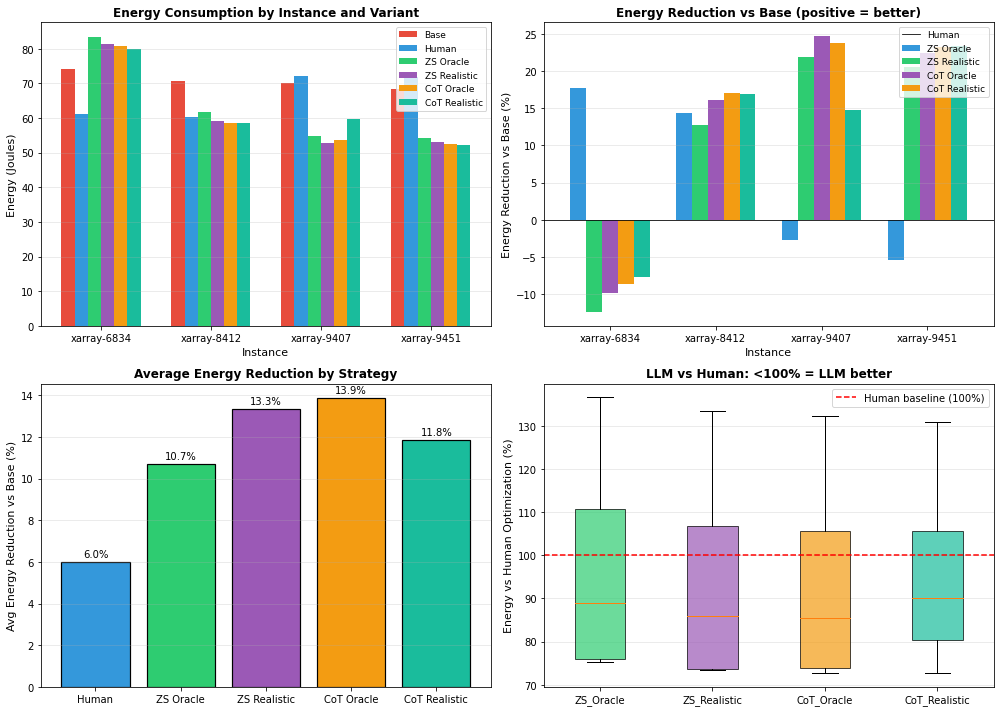

In [7]:
# Cella 4: Grafici comparativi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Colori
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

# === GRAFICO 1: Energia assoluta per istanza ===
ax1 = axes[0, 0]
x = np.arange(len(df))
width = 0.12

for i, (col, label) in enumerate(zip(VARIANTS, VARIANT_LABELS)):
    ax1.bar(x + i*width, df[col], width, label=label, color=colors[i])

ax1.set_xlabel('Instance', fontsize=11)
ax1.set_ylabel('Energy (Joules)', fontsize=11)
ax1.set_title('Energy Consumption by Instance and Variant', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels(df.index, rotation=0)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# === GRAFICO 2: Riduzione % vs Base ===
ax2 = axes[0, 1]
df_red = df_reduction.drop(columns=['Base'])
df_red.plot(kind='bar', ax=ax2, color=colors[1:], width=0.75)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Instance', fontsize=11)
ax2.set_ylabel('Energy Reduction vs Base (%)', fontsize=11)
ax2.set_title('Energy Reduction vs Base (positive = better)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(df.index, rotation=0)
ax2.legend(['Human', 'ZS Oracle', 'ZS Realistic', 'CoT Oracle', 'CoT Realistic'], 
           loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# === GRAFICO 3: Media riduzione per strategia ===
ax3 = axes[1, 0]
mean_reduction = df_reduction.drop(columns=['Base']).mean()
bars = ax3.bar(VARIANT_LABELS[1:], mean_reduction, color=colors[1:], edgecolor='black', linewidth=1.2)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('Avg Energy Reduction vs Base (%)', fontsize=11)
ax3.set_title('Average Energy Reduction by Strategy', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Aggiungi valori sopra le barre
for bar, val in zip(bars, mean_reduction):
    height = bar.get_height()
    ax3.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# === GRAFICO 4: LLM vs Human (boxplot) ===
ax4 = axes[1, 1]
llm_vs_human = pd.DataFrame()
for col in ['Head_ZS_Oracle', 'Head_ZS_Realistic', 'Head_CoT_Oracle', 'Head_CoT_Realistic']:
    label = col.replace('Head_', '')
    llm_vs_human[label] = (df[col] / df['Head'] * 100)

bp = ax4.boxplot(llm_vs_human.values, labels=llm_vs_human.columns, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[2:]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Human baseline (100%)')
ax4.set_ylabel('Energy vs Human Optimization (%)', fontsize=11)
ax4.set_title('LLM vs Human: <100% = LLM better', fontsize=12, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/green/eda_energy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Grafico salvato: data/processed/green/eda_energy_comparison.png")

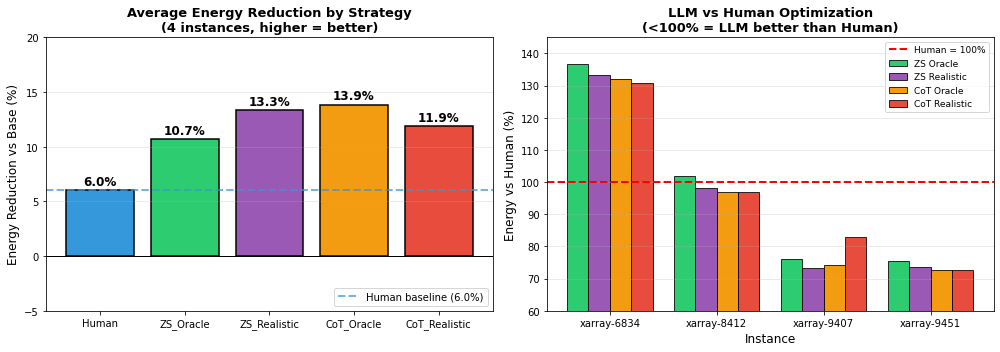


📊 TABLE 1: Energy Reduction vs Base (%) - PRELIMINARY RESULTS (n=4)
   Instance  Human  ZS Oracle  ZS Realistic  CoT Oracle  CoT Realistic
xarray-6834   17.7      -12.4         -9.80      -8.700          -7.70
xarray-8412   14.4       12.7         16.10      17.100          16.90
xarray-9407   -2.7       21.9         24.70      23.800          14.80
xarray-9451   -5.4       20.6         22.40      23.300          23.40
       MEAN    6.0       10.7         13.35      13.875          11.85

📊 TABLE 2: LLM vs Human (%) - <100% means LLM is better
   Instance  ZS Oracle  ZS Realistic  CoT Oracle  CoT Realistic
xarray-6834    136.600       133.400     132.200        130.900
xarray-8412    102.000        98.000      96.900         97.100
xarray-9407     76.100        73.400      74.200         83.000
xarray-9451     75.400        73.700      72.800         72.700
       MEAN     97.525        94.625      94.025         95.925

🎯 KEY FINDINGS (Preliminary, n=4 instances)

✅ All LLM strategi

In [9]:
# Cella 5: Grafici e Tabelle per la presentazione
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# === SETUP DATI ===
COMPLETE_IDS = ['pydata__xarray-6834', 'pydata__xarray-8412', 'pydata__xarray-9407', 'pydata__xarray-9451']
VARIANTS = ['Base', 'Head', 'Head_ZS_Oracle', 'Head_ZS_Realistic', 'Head_CoT_Oracle', 'Head_CoT_Realistic']

# Estrai dati
data = []
for inst in dataset['instances']:
    if inst['instance_id'] in COMPLETE_IDS:
        row = {'Instance': inst['instance_id'].replace('pydata__xarray-', 'xarray-')}
        for v in VARIANTS:
            row[v] = inst['metrics'][v].get('total_energy_joules', np.nan)
        data.append(row)

df = pd.DataFrame(data).set_index('Instance')

# Calcola riduzioni vs Base
df_reduction = pd.DataFrame(index=df.index)
for col in df.columns:
    df_reduction[col] = ((df['Base'] - df[col]) / df['Base'] * 100)

# ============================================================
# FIGURA 1: Grafico principale per presentazione
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_main = {'Human': '#3498db', 'ZS_Oracle': '#2ecc71', 'ZS_Realistic': '#9b59b6', 
               'CoT_Oracle': '#f39c12', 'CoT_Realistic': '#e74c3c'}

# --- Grafico 1: Riduzione media per strategia ---
ax1 = axes[0]
strategies = ['Human', 'ZS_Oracle', 'ZS_Realistic', 'CoT_Oracle', 'CoT_Realistic']
means = [df_reduction['Head'].mean(), df_reduction['Head_ZS_Oracle'].mean(), 
         df_reduction['Head_ZS_Realistic'].mean(), df_reduction['Head_CoT_Oracle'].mean(),
         df_reduction['Head_CoT_Realistic'].mean()]

bars = ax1.bar(strategies, means, color=[colors_main[s] for s in strategies], 
               edgecolor='black', linewidth=1.5)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.axhline(y=means[0], color='#3498db', linestyle='--', linewidth=2, alpha=0.7, label=f'Human baseline ({means[0]:.1f}%)')

for bar, val in zip(bars, means):
    ax1.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val),
                 xytext=(0, 5), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

ax1.set_ylabel('Energy Reduction vs Base (%)', fontsize=12)
ax1.set_title('Average Energy Reduction by Strategy\n(4 instances, higher = better)', fontsize=13, fontweight='bold')
ax1.set_ylim(-5, 20)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# --- Grafico 2: LLM vs Human per istanza ---
ax2 = axes[1]
llm_strategies = ['ZS_Oracle', 'ZS_Realistic', 'CoT_Oracle', 'CoT_Realistic']
x = np.arange(len(df))
width = 0.2

for i, strat in enumerate(llm_strategies):
    col = f'Head_{strat}'
    vs_human = (df[col] / df['Head'] * 100).values
    bars = ax2.bar(x + i*width, vs_human, width, label=strat.replace('_', ' '), 
                   color=colors_main[strat], edgecolor='black', linewidth=0.8)

ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Human = 100%')
ax2.set_xlabel('Instance', fontsize=12)
ax2.set_ylabel('Energy vs Human (%)', fontsize=12)
ax2.set_title('LLM vs Human Optimization\n(<100% = LLM better than Human)', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(df.index, fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(60, 145)

plt.tight_layout()
plt.savefig('presentation_main_figure.png', dpi=200, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# ============================================================
# TABELLA 1: Risultati principali
# ============================================================
print("\n" + "="*90)
print("📊 TABLE 1: Energy Reduction vs Base (%) - PRELIMINARY RESULTS (n=4)")
print("="*90)

table1 = pd.DataFrame({
    'Instance': df.index,
    'Human': df_reduction['Head'].values.round(1),
    'ZS Oracle': df_reduction['Head_ZS_Oracle'].values.round(1),
    'ZS Realistic': df_reduction['Head_ZS_Realistic'].values.round(1),
    'CoT Oracle': df_reduction['Head_CoT_Oracle'].values.round(1),
    'CoT Realistic': df_reduction['Head_CoT_Realistic'].values.round(1),
})
table1.loc['MEAN'] = ['MEAN'] + [table1[col].mean() for col in table1.columns[1:]]
print(table1.to_string(index=False))

# ============================================================
# TABELLA 2: LLM vs Human
# ============================================================
print("\n" + "="*90)
print("📊 TABLE 2: LLM vs Human (%) - <100% means LLM is better")
print("="*90)

table2 = pd.DataFrame({
    'Instance': df.index,
    'ZS Oracle': ((df['Head_ZS_Oracle'] / df['Head']) * 100).values.round(1),
    'ZS Realistic': ((df['Head_ZS_Realistic'] / df['Head']) * 100).values.round(1),
    'CoT Oracle': ((df['Head_CoT_Oracle'] / df['Head']) * 100).values.round(1),
    'CoT Realistic': ((df['Head_CoT_Realistic'] / df['Head']) * 100).values.round(1),
})
table2.loc['MEAN'] = ['MEAN'] + [table2[col].mean() for col in table2.columns[1:]]
print(table2.to_string(index=False))

# ============================================================
# SUMMARY BOX
# ============================================================
print("\n" + "="*90)
print("🎯 KEY FINDINGS (Preliminary, n=4 instances)")
print("="*90)
print(f"""
✅ All LLM strategies outperform Human optimization on average:
   • Human:         {means[0]:+.1f}% energy reduction
   • ZS Oracle:     {means[1]:+.1f}% energy reduction  
   • ZS Realistic:  {means[2]:+.1f}% energy reduction
   • CoT Oracle:    {means[3]:+.1f}% energy reduction (BEST)
   • CoT Realistic: {means[4]:+.1f}% energy reduction

⚠️  Human optimization INCREASED energy in 2/4 cases (xarray-9407, xarray-9451)

🔍 LLM vs Human (lower = better):
   • ZS Realistic:  {((df['Head_ZS_Realistic'] / df['Head']) * 100).mean():.1f}% of human energy
   • CoT Realistic: {((df['Head_CoT_Realistic'] / df['Head']) * 100).mean():.1f}% of human energy
   
📝 Note: Results limited to 4 xarray instances. More data needed for generalization.
""")

print("\n💾 Figure saved: presentation_main_figure.png")